# Test Notebook 8
# FMU Memory Footprint Without Native Release

`FMUComponent` no longer calls `fmi2Terminate` or `fmi2FreeInstance`, and no longer deletes the
directory an FMU is extracted into. That workaround exists because freeing the CVODE pendulum FMU
corrupts the heap (issues.md HARD-05). This notebook measures what the workaround costs.

The question it answers is whether the retained instances are Python objects that the garbage
collector will eventually reclaim, or native allocations that only an FMI call can release.

## What is allocated, and by whom

Creating one usable FMU goes through three allocations that live in different places.

`fmpy.extract()` unpacks the `.fmu` archive into a fresh temporary directory. That is disk, owned by
nobody until someone removes it.

`FMU2Slave(...)` loads the model's shared library through `ctypes` and keeps a handle to it. The
Python wrapper is small; the loaded library is not, and `ctypes` keeps it mapped for the lifetime of
the process unless the handle is freed explicitly.

`instantiate()` calls `fmi2Instantiate`, and the FMU allocates its own state on the C heap. Python
knows nothing about that block. It is reachable only through the opaque component pointer the FMU
returned, and only `fmi2FreeInstance` can give it back.

Reference counting and the garbage collector manage the first of these three and none of the other
two, which is what the experiments below check rather than assume.

In [1]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [2]:
import gc
import json
import os
import subprocess
import tracemalloc

import matplotlib.pyplot as plt
import pandas as pd
import psutil

from fmpy.fmi2 import FMU2Slave

from syssimx import FMUComponent, Connection, System

### Does fmpy free anything on its own?

If `FMU2Slave` defined a finalizer, dropping the last Python reference would terminate and free the
native instance, and no explicit call would be needed. It does not.

In [3]:
has_finalizer = any("__del__" in vars(klass) for klass in FMU2Slave.__mro__)
native_calls = [name for name in ("instantiate", "terminate", "freeInstance", "freeLibrary")
                if hasattr(FMU2Slave, name)]

print(f"fmpy version                    : {__import__('fmpy').__version__}")
print(f"FMU2Slave defines a finalizer   : {has_finalizer}")
print(f"native lifecycle calls available: {native_calls}")
print()
print("Without a finalizer, garbage collecting the wrapper cannot call fmi2FreeInstance.")
print("The native allocation therefore outlives the Python object that referenced it.")

fmpy version                    : 0.3.30
FMU2Slave defines a finalizer   : False
native lifecycle calls available: ['instantiate', 'terminate', 'freeInstance', 'freeLibrary']

Without a finalizer, garbage collecting the wrapper cannot call fmi2FreeInstance.
The native allocation therefore outlives the Python object that referenced it.


## Measurement

Three quantities are tracked side by side, because only their combination separates Python memory
from native memory.

`rss` is the resident set size of this process, which counts every allocation regardless of who made
it. `python_heap` is what `tracemalloc` attributes to Python allocations. `extracted` is the size on
disk of the extraction directories that the components created.

An allocation that raises `rss` while leaving `python_heap` flat is native memory, invisible to the
garbage collector.

In [4]:
PROCESS = psutil.Process(os.getpid())
MB = 1024 ** 2


def rss_mb() -> float:
    return PROCESS.memory_info().rss / MB


def python_heap_mb() -> float:
    current, _peak = tracemalloc.get_traced_memory()
    return current / MB


def dir_size_mb(path) -> float:
    path = Path(path)
    if not path.exists():
        return 0.0
    return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / MB


def extracted_mb(unzipdirs) -> float:
    return sum(dir_size_mb(p) for p in unzipdirs)


tracemalloc.start()
gc.collect()
BASELINE_RSS = rss_mb()
print(f"baseline rss = {BASELINE_RSS:.1f} MB")

baseline rss = 239.7 MB


## FMU discovery

The components come from the controlled-pendulum demo, the same artifacts the quantization case
study uses.

In [5]:
PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
        for subsubdir in subdir.iterdir():
            if subsubdir.is_dir():
                fmu_paths[subdir.name][subsubdir.name] = {}
                for fmu_file in subsubdir.glob("*.fmu"):
                    fmu_paths[subdir.name][subsubdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

QUANTIZATION_FMUS = {
    "Setpoint": fmu_paths["Trajectories"]["SetPoint"],
    "PID": fmu_paths["Controllers"]["PIDController"],
    "Drive": fmu_paths["Actuators"]["DriveDynamic"],
    "Angle Sensor": fmu_paths["Sensors"]["AngleSensor"],
    "Angle Decoder": fmu_paths["Sensors"]["AngleDecoder"],
    "Pendulum": fmu_paths["Plants"]["Pendulum_cvode"],
}

for name, path in QUANTIZATION_FMUS.items():
    print(f"{name:>14}: {path.name} ({path.stat().st_size / MB:.2f} MB on disk)")

      Setpoint: SetPoint.fmu (1.26 MB on disk)
           PID: PIDController.fmu (1.28 MB on disk)
         Drive: DriveDynamic.fmu (1.27 MB on disk)
  Angle Sensor: AngleSensor.fmu (1.27 MB on disk)
 Angle Decoder: AngleDecoder.fmu (1.27 MB on disk)
      Pendulum: Pendulum_cvode.fmu (1.27 MB on disk)


## Experiment 1: repeated initialization of one component

`initialize()` extracts the archive and instantiates the FMU. `reset()` drops the Python reference to
that instance without releasing it. Cycling the two is what a parameter study does between cases.

The plant FMU is used here because it is the largest of the six and the one HARD-05 concerns.

In [6]:
CYCLES = 10

component = FMUComponent(name="Pendulum", fmu_path=QUANTIZATION_FMUS["Pendulum"])
unzipdirs = []
rows = []

gc.collect()
rss_before = rss_mb()
heap_before = python_heap_mb()

for cycle in range(1, CYCLES + 1):
    component.reset()
    component.initialize(t0=0.0)
    unzipdirs.append(str(component._unzipdir))
    gc.collect()
    rows.append({
        "cycle": cycle,
        "rss": rss_mb(),
        "d_rss": rss_mb() - rss_before,
        "python_heap": python_heap_mb(),
        "d_python_heap": python_heap_mb() - heap_before,
        "extraction_dirs": len(set(unzipdirs)),
        "extracted": extracted_mb(set(unzipdirs)),
    })

df_single = pd.DataFrame(rows)
df_single.style.format({
    "rss": "{:.1f}", "d_rss": "{:.1f}", "python_heap": "{:.2f}",
    "d_python_heap": "{:.2f}", "extracted": "{:.1f}",
})

,cycle,rss,d_rss,python_heap,d_python_heap,extraction_dirs,extracted
0,1,246.8,2.7,0.97,0.06,1,5.1
1,2,247.2,3.1,0.97,0.06,2,10.2
2,3,248.1,4.0,0.98,0.06,3,15.4
3,4,248.4,4.3,0.98,0.06,4,20.5
4,5,248.8,4.6,0.98,0.06,5,25.6
5,6,249.1,5.0,0.98,0.06,6,30.7
6,7,249.4,5.3,0.98,0.06,7,35.8
7,8,249.8,5.6,0.98,0.06,8,40.9
8,9,250.1,6.0,0.98,0.07,9,46.1
9,10,250.4,6.3,0.98,0.07,10,51.2


In [7]:
per_cycle_rss = df_single["d_rss"].iloc[-1] / CYCLES
per_cycle_disk = df_single["extracted"].iloc[-1] / CYCLES

print(f"cycles                    : {CYCLES}")
print(f"resident growth           : {df_single['d_rss'].iloc[-1]:.1f} MB "
      f"({per_cycle_rss:.2f} MB per cycle)")
print(f"python heap growth        : {df_single['d_python_heap'].iloc[-1]:.2f} MB")
print(f"extraction directories    : {df_single['extraction_dirs'].iloc[-1]} "
      f"({df_single['extracted'].iloc[-1]:.1f} MB, {per_cycle_disk:.2f} MB per cycle)")
print()
print("Every cycle leaves one live native instance and one extraction directory behind.")
print("Only one of them is reachable from Python; the rest cannot be freed any more.")

cycles                    : 10
resident growth           : 6.3 MB (0.63 MB per cycle)
python heap growth        : 0.07 MB
extraction directories    : 10 (51.2 MB, 5.12 MB per cycle)

Every cycle leaves one live native instance and one extraction directory behind.
Only one of them is reachable from Python; the rest cannot be freed any more.


## Experiment 2: the quantization system

The same cycle at system scale. `02_quantization.ipynb` runs its parameter study exactly this way:
`system.reset()`, `system.initialize()`, `system.run()`, once per case, over six FMU components.

In [8]:
def build_quantization_system():
    components = {
        name: FMUComponent(name=name, fmu_path=path)
        for name, path in QUANTIZATION_FMUS.items()
    }
    connections = [
        Connection("Setpoint", "theta_ref", "PID", "theta_ref"),
        Connection("Pendulum", "theta", "Angle Sensor", "theta"),
        Connection("Angle Sensor", "v_out", "Angle Decoder", "v_in"),
        Connection("Angle Decoder", "theta", "PID", "theta_meas"),
        Connection("PID", "u", "Drive", "u_control"),
        Connection("Drive", "torque", "Pendulum", "tau"),
        Connection("Pendulum", "omega", "Drive", "omega"),
    ]
    system = System(name="Quantization")
    for comp in components.values():
        system.add_component(comp)
    for conn in connections:
        system.add_connection(conn)
    return system, components


system, components = build_quantization_system()
print(f"{len(components)} FMU components, {len(system.connections)} connections")

6 FMU components, 7 connections


In [9]:
SYSTEM_CYCLES = 6
T_END = 0.2
DT = 1e-3

system_unzipdirs = []
rows = []

gc.collect()
rss_before = rss_mb()
heap_before = python_heap_mb()

for cycle in range(1, SYSTEM_CYCLES + 1):
    system.reset()
    system.initialize(t0=0.0)
    system.run(0.0, T_END, DT)
    system_unzipdirs.extend(str(comp._unzipdir) for comp in components.values())
    gc.collect()
    rows.append({
        "cycle": cycle,
        "rss": rss_mb(),
        "d_rss": rss_mb() - rss_before,
        "d_python_heap": python_heap_mb() - heap_before,
        "extraction_dirs": len(set(system_unzipdirs)),
        "extracted": extracted_mb(set(system_unzipdirs)),
    })

df_system = pd.DataFrame(rows)
df_system.style.format({
    "rss": "{:.1f}", "d_rss": "{:.1f}", "d_python_heap": "{:.2f}", "extracted": "{:.1f}",
})

,cycle,rss,d_rss,d_python_heap,extraction_dirs,extracted
0,1,259.9,4.3,0.38,6,30.8
1,2,262.0,6.4,0.38,12,61.6
2,3,264.5,8.9,0.39,18,92.4
3,4,266.3,10.7,0.39,24,123.2
4,5,268.1,12.6,0.39,30,154.0
5,6,270.0,14.4,0.39,36,184.8


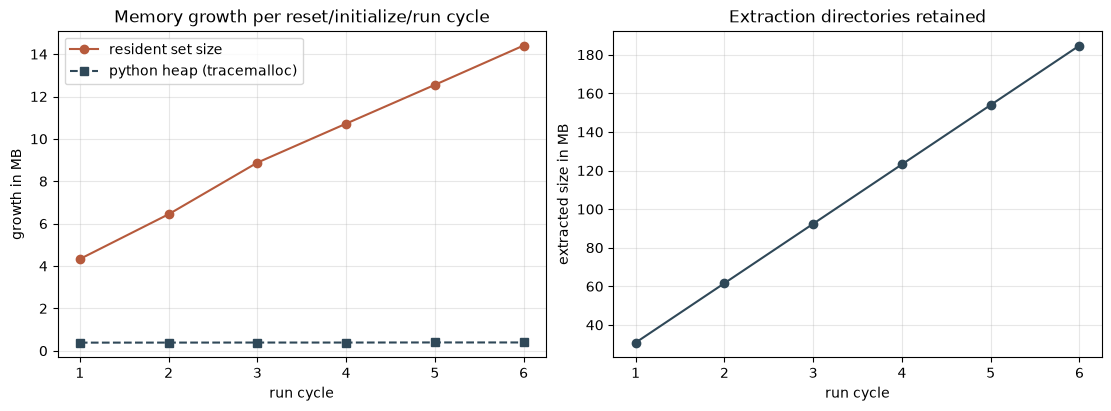

In [10]:
fig, (ax_mem, ax_disk) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax_mem.plot(df_system["cycle"], df_system["d_rss"], "o-", color="#B65A3C",
            label="resident set size")
ax_mem.plot(df_system["cycle"], df_system["d_python_heap"], "s--", color="#2F4858",
            label="python heap (tracemalloc)")
ax_mem.set_xlabel("run cycle")
ax_mem.set_ylabel("growth in MB")
ax_mem.set_title("Memory growth per reset/initialize/run cycle")
ax_mem.grid(True, alpha=0.3)
ax_mem.legend()

ax_disk.plot(df_system["cycle"], df_system["extracted"], "o-", color="#2F4858")
ax_disk.set_xlabel("run cycle")
ax_disk.set_ylabel("extracted size in MB")
ax_disk.set_title("Extraction directories retained")
ax_disk.grid(True, alpha=0.3)

plt.show()

## Experiment 3: does dropping the Python reference give anything back?

This is the hypothesis under test. The component is deleted and a full collection is forced. If the
retained memory were Python's, the resident set would fall back.

In [11]:
probe = FMUComponent(name="Probe", fmu_path=QUANTIZATION_FMUS["Pendulum"])
probe.initialize(t0=0.0)
probe_unzipdir = str(probe._unzipdir)

gc.collect()
rss_with_component = rss_mb()

del probe
collected = gc.collect()
rss_after_delete = rss_mb()

print(f"rss holding the component : {rss_with_component:.1f} MB")
print(f"objects collected         : {collected}")
print(f"rss after del + collect   : {rss_after_delete:.1f} MB")
print(f"reclaimed                 : {rss_with_component - rss_after_delete:.2f} MB")
print(f"extraction dir still there: {Path(probe_unzipdir).exists()} "
      f"({dir_size_mb(probe_unzipdir):.1f} MB)")
print()
print("Deleting the wrapper reclaims the wrapper. The native instance is now unreachable,")
print("which makes it unfreeable: the pointer that fmi2FreeInstance needs went with the object.")

rss holding the component : 279.1 MB
objects collected         : 316
rss after del + collect   : 279.1 MB
reclaimed                 : 0.00 MB
extraction dir still there: True (5.1 MB)

Deleting the wrapper reclaims the wrapper. The native instance is now unreachable,
which makes it unfreeable: the pointer that fmi2FreeInstance needs went with the object.


## Experiment 4: what an explicit release would return

The control case. Instances are created, then terminated, freed, their libraries unloaded and their
extraction directories removed, and the resident set is measured on both sides.

This runs in a subprocess on purpose. `fmi2FreeInstance` is the call that corrupts the heap for the
CVODE plant FMU, and a corrupted heap takes the whole process down. Isolating it keeps this
notebook's kernel alive and turns the crash into a result: the same script is run against a simple
FMU and against the plant FMU, and the exit code says which one survived.

In [12]:
FREE_PROBE = r'''
import json, os, shutil, sys
sys.path.insert(0, sys.argv[1])
import psutil
from syssimx import FMUComponent

fmu_path, n = sys.argv[2], int(sys.argv[3])
process = psutil.Process(os.getpid())
mb = lambda: process.memory_info().rss / 1024 ** 2

comps = []
for i in range(n):
    c = FMUComponent(name=f"probe{i}", fmu_path=fmu_path)
    c.initialize(t0=0.0)
    comps.append(c)
held = mb()

for c in comps:
    c._instance.terminate()
    c._instance.freeInstance()
    c._instance.freeLibrary()
    shutil.rmtree(c._unzipdir, ignore_errors=True)
released = mb()

print(json.dumps({"held": held, "released": released, "reclaimed": held - released}))
'''


def measure_release(fmu_path, n=4):
    completed = subprocess.run(
        [sys.executable, "-c", FREE_PROBE, str(_repo), str(fmu_path), str(n)],
        capture_output=True, text=True,
    )
    code_hex = f"0x{completed.returncode & 0xFFFFFFFF:08X}"
    if completed.returncode != 0:
        return {"status": f"crashed, exit {code_hex}", "held": float("nan"),
                "released": float("nan"), "reclaimed": float("nan")}
    payload = json.loads(completed.stdout.strip().splitlines()[-1])
    payload["status"] = "released cleanly"
    return payload


release_rows = []
for label, path in (("Setpoint", QUANTIZATION_FMUS["Setpoint"]),
                    ("Pendulum (cvode)", QUANTIZATION_FMUS["Pendulum"])):
    result = measure_release(path)
    release_rows.append({"fmu": label, **result})
    print(f"{label:>18}: {result['status']}")

df_release = pd.DataFrame(release_rows)[["fmu", "status", "held", "released", "reclaimed"]]
df_release.style.format({"held": "{:.1f}", "released": "{:.1f}", "reclaimed": "{:.1f}"},
                        na_rep="-")

          Setpoint: released cleanly
  Pendulum (cvode): crashed, exit 0xC0000374


,fmu,status,held,released,reclaimed
0,Setpoint,released cleanly,205.3,204.3,1.0
1,Pendulum (cvode),"crashed, exit 0xC0000374",-,-,-


## Summary

In [13]:
summary = pd.DataFrame([
    {
        "measurement": "one component, per initialize cycle",
        "rss_MB": df_single["d_rss"].iloc[-1] / CYCLES,
        "disk_MB": df_single["extracted"].iloc[-1] / CYCLES,
    },
    {
        "measurement": "quantization system, per run cycle (6 FMUs)",
        "rss_MB": df_system["d_rss"].iloc[-1] / SYSTEM_CYCLES,
        "disk_MB": df_system["extracted"].iloc[-1] / SYSTEM_CYCLES,
    },
    {
        "measurement": "python heap share of the system growth",
        "rss_MB": df_system["d_python_heap"].iloc[-1] / SYSTEM_CYCLES,
        "disk_MB": 0.0,
    },
])
summary["MB per 100 cycles"] = summary["rss_MB"] * 100

display_cols = ["measurement", "rss_MB", "disk_MB", "MB per 100 cycles"]
summary[display_cols].style.format({
    "rss_MB": "{:.2f}", "disk_MB": "{:.2f}", "MB per 100 cycles": "{:.0f}",
}).hide(axis="index")

measurement,rss_MB,disk_MB,MB per 100 cycles
"one component, per initialize cycle",0.63,5.12,63
"quantization system, per run cycle (6 FMUs)",2.40,30.80,240
python heap share of the system growth,0.07,0.00,7


## Housekeeping

The measurement leaves its own evidence behind, which is worth reporting rather than hiding.

In [14]:
leftover = sorted({*unzipdirs, *system_unzipdirs, probe_unzipdir})
leftover = [path for path in leftover if Path(path).exists()]

# The location is deliberately not printed: it is an absolute machine path and
# this notebook is tracked (issues.md HARD-06).
print(f"extraction directories left by this notebook: {len(leftover)}")
print(f"total size                                  : {extracted_mb(leftover):.1f} MB")
print("location                                    : the system temporary directory, "
      "tempfile.gettempdir()")
print()
print("Windows keeps every loaded model DLL locked while this kernel lives, so these")
print("directories can only be removed after the kernel exits. Each execution of this")
print("notebook adds another set.")

extraction directories left by this notebook: 47
total size                                  : 241.1 MB
location                                    : the system temporary directory, tempfile.gettempdir()

Windows keeps every loaded model DLL locked while this kernel lives, so these
directories can only be removed after the kernel exits. Each execution of this
notebook adds another set.


## Conclusion

The retained memory is not Python's to collect. `fmpy` wraps the native instance in a `FMU2Slave`
object without a finalizer, so dropping that object reclaims the wrapper and strands the C
allocation behind it: the resident set stays where it was while `tracemalloc` reports almost nothing,
and the pointer needed to call `fmi2FreeInstance` is gone. Neither `fmpy` nor the FMI library owns
that cleanup. The FMI standard puts it on the caller, which is `FMUComponent`.

That makes the HARD-05 workaround a real cost rather than a bookkeeping detail. Every
`initialize()`, every `reinitialize_instance()` during hybrid rollback, and every mode switch in
`MasterPendulum` adds one resident instance and one extraction directory for the rest of the
process.

For the current notebooks and tests this is affordable: they initialize a handful of times and the
kernel exits. It is not affordable for a long parameter study, a many-switch run, or a service that
keeps a kernel alive, and the measured per-cycle figures above are what such a run would pay.

The control experiment shows the memory is reclaimable in principle, and which FMU makes reclaiming
it unsafe. Restoring the release path in `FMUComponent` therefore depends on fixing the CVODE export
first, which is what HARD-05 tracks.